<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Resume_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ================================================
# **RESUME ANALYZER PROJECT (END-TO-END NLP PIPELINE)**
# ================================================

# **INSTALL LIBRARIES**

In [32]:
!pip install PyPDF2 spacy scikit-learn sentence-transformers matplotlib
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **IMPORT LIBRARIES**

In [33]:
import re
import json
import PyPDF2
import spacy
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# **LOAD NLP MODEL**

In [34]:
nlp = spacy.load("en_core_web_sm")

# **UPLOAD RESUME PDF**

In [35]:
uploaded = files.upload()

Saving Document (1).pdf to Document (1) (2).pdf


# **EXTRACT TEXT FROM PDF**

In [36]:
def extract_text_from_pdf(file):

    reader = PyPDF2.PdfReader(file)

    text = ""

    for page in reader.pages:
        extracted = page.extract_text()

        if extracted:
            text += extracted

    return text

# **GET RESUME TEXT**

In [38]:
file_name = list(uploaded.keys())[0]

resume_text = extract_text_from_pdf(file_name)

print("\n================ RESUME PREVIEW ================\n")
print(resume_text[:1000])


================ RESUME PREVIEW ================

MUNEEER AHMAD DAR  
Aspiring Data Analyst | ML Fundamentals  
India | (91) 95410 -51960 | abrard855@gmail.com  | LinkedIn: /muneerahmad -826363267  | 
GitHub: /muneer -ahmad10  
 
PROFESSIONAL SUMMARY  
Highly motivated and results -driven Fresher  with a strong foundation in Data 
Analysis, Exploratory Data Analysis (EDA),  and Machine Learning fundamentals . 
Proficient in utilizing Python (Pandas, NumPy, Matplotlib, Seaborn, Scikit -learn)  and 
SQL  for data cleaning, visualization, model building, and extracting actionable insights. 
Proven ability to handle structured datasets and deliver data -driven solutions through 
hands -on projects on Kaggle and GitHub. Actively seeking an entry -level Data Analyst / 
ML Inte rn role to apply analytical and modeling skills in a dynamic business 
environment.  
 
TECHNICAL SKILLS  
Category  Skills  
Programming  Python (Advanced), SQL  
Data Analysis  Pandas, NumPy, Exploratory Data Analys

# **TEXT PREPROCESSING**

In [39]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9 ]', ' ', text)

    text = " ".join(text.split())

    return text

# **JOB DESCRIPTION**

In [40]:
job_description = """

We are looking for an NLP / ML Engineer with strong experience in
Python, Machine Learning, Deep Learning, NLP, SQL, PyTorch,
TensorFlow, APIs, RAG pipelines, Azure, Streamlit and MLOps.

Candidate should understand semantic search, vector databases,
LLMs, document understanding and AI workflows.

"""

# **CLEAN TEXT**

In [41]:
resume_clean = clean_text(resume_text)

job_clean = clean_text(job_description)

# **KEYWORD EXTRACTION USING N-GRAMS**

In [42]:
def extract_keywords(text):

    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=100
    )

    X = vectorizer.fit_transform([text])

    keywords = vectorizer.get_feature_names_out()

    return list(keywords)

# **SKILLS DATABASE**

In [43]:
SKILLS_DB = [

    "python",
    "machine learning",
    "deep learning",
    "nlp",
    "sql",
    "pytorch",
    "tensorflow",
    "streamlit",
    "rag",
    "azure",
    "mlops",
    "api",
    "apis",
    "vector databases",
    "semantic search",
    "document understanding",
    "llms",
    "data analysis",
    "pandas",
    "numpy",
    "scikit learn",
    "xgboost",
    "transformers"

]

# **EXTRACT SKILLS**

In [44]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in SKILLS_DB:

        if skill in text:
            found_skills.append(skill)

    return list(set(found_skills))

# **GET JOB & RESUME SKILLS**

In [45]:
job_skills = extract_skills(job_clean)

resume_skills = extract_skills(resume_clean)

# **MATCHED & MISSING SKILLSn**

In [46]:
matched_skills = list(set(job_skills) & set(resume_skills))

missing_skills = list(set(job_skills) - set(resume_skills))

In [ ]:
# 1. Prepare the text
resume = resume_text
job = Data_science_job_desc

# 2. Clean the text
resume_clean = clean_text(resume)
job_clean = clean_text(job)

# 3. Extract skills using your new functions
job_skills = extract_skills_from_job(job_clean)
resume_skills = extract_skills_from_resume(resume_clean)

# 4. Calculate metrics
matched = list(set(job_skills) & set(resume_skills))
missing = list(set(job_skills) - set(resume_skills))
score = compute_similarity(resume_clean, job_clean)

# 5. Print Results
print(f"--- Analysis Results ---")
print(f"Match Score: {score}%")
print(f"Matched Skills: {matched}")
print(f"Missing Skills: {missing}")

# **SKILL MATCH SCORE**

In [47]:
skill_match_score = (len(matched_skills) / len(job_skills)) * 100

# **SEMANTIC SIMILARITY USING EMBEDDINGS**

In [48]:
model = SentenceTransformer('all-MiniLM-L6-v2')

def compute_similarity(resume, job):

    emb1 = model.encode([resume])

    emb2 = model.encode([job])

    score = cosine_similarity(emb1, emb2)[0][0]

    return round(score * 100, 2)

semantic_score = compute_similarity(resume_clean, job_clean)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# **FINAL VERDICT**

In [49]:
if semantic_score > 75:

    verdict = "Strong Match........"

elif semantic_score > 50:

    verdict = "Moderate Match....."

else:

    verdict = "Low Match....."

# **RECOMMENDATIONS**

In [50]:
recommendations = {

    "tensorflow": "Learn Deep Learning using TensorFlow",

    "pytorch": "Build Deep Learning projects using PyTorch",

    "azure": "Explore Azure AI Services",

    "mlops": "Learn model deployment and monitoring",

    "streamlit": "Build ML web apps using Streamlit",

    "rag": "Understand Retrieval-Augmented Generation",

    "vector databases": "Learn FAISS or Pinecone",

    "semantic search": "Study embedding similarity systems",

    "transformers": "Learn HuggingFace Transformers"

}

print("\n================ RECOMMENDATIONS ================\n")

for skill in missing_skills:

    if skill in recommendations:

        print(f"{skill} --> {recommendations[skill]}")


================ RECOMMENDATIONS ================

tensorflow --> Learn Deep Learning using TensorFlow
mlops --> Learn model deployment and monitoring
azure --> Explore Azure AI Services
vector databases --> Learn FAISS or Pinecone
pytorch --> Build Deep Learning projects using PyTorch
streamlit --> Build ML web apps using Streamlit
semantic search --> Study embedding similarity systems


# **FINAL RESULTS**

In [51]:
print("\n================ FINAL ANALYSIS ================\n")

print(f"Semantic Match Score: {semantic_score}%")

print(f"\nSkill Match Score: {round(skill_match_score,2)}%")

print(f"\nVerdict: {verdict}")

print(f"\nMatched Skills:\n{matched_skills}")

print(f"\nMissing Skills:\n{missing_skills}")


================ FINAL ANALYSIS ================

Semantic Match Score: 48.029998779296875%

Skill Match Score: 23.53%

Verdict: Low Match.....

Matched Skills:
['rag', 'sql', 'python', 'machine learning']

Missing Skills:
['document understanding', 'tensorflow', 'mlops', 'api', 'llms', 'azure', 'vector databases', 'nlp', 'pytorch', 'streamlit', 'apis', 'deep learning', 'semantic search']


# **VISUALIZATION**

## **BAR CHART**

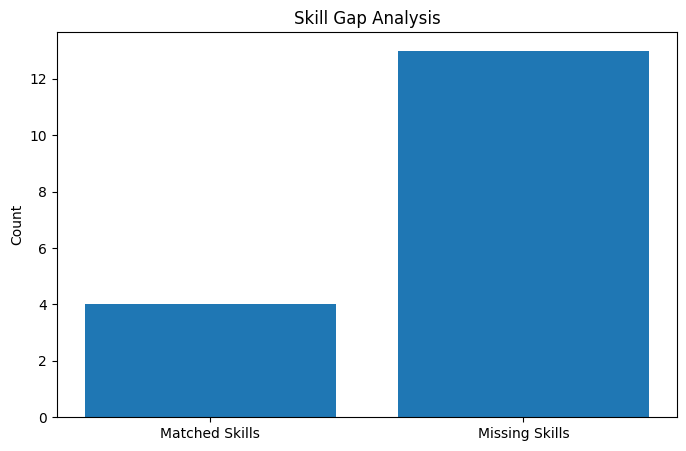

In [52]:
labels = ['Matched Skills', 'Missing Skills']

counts = [len(matched_skills), len(missing_skills)]

plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.title("Skill Gap Analysis")

plt.ylabel("Count")

plt.show()

## **PIE CHART**

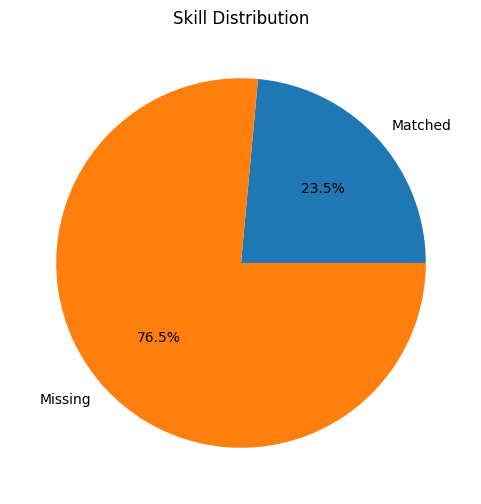

In [53]:
plt.figure(figsize=(6,6))

plt.pie(

    [len(matched_skills), len(missing_skills)],

    labels=['Matched', 'Missing'],

    autopct='%1.1f%%'

)

plt.title("Skill Distribution")

plt.show()

# **SAVE RESULTS**

In [55]:
results = {

    "Semantic Match Score": semantic_score,

    "Skill Match Score": round(skill_match_score,2),

    "Verdict": verdict,

    "Matched Skills": matched_skills,

    "Missing Skills": missing_skills

}

print("\n Results saved as results")


 Results saved as results
